In [33]:
import serial
import numpy as np
import time
from matplotlib import pyplot as plt
from ribbn_scripts.hardware_api.hardware import Exciter,Tag

In [34]:
com_port1="/dev/tty.usbmodem1101"
tag1=Tag(com_port1)
# tag1.connect_wifi("192.168.1.24", 3333)
print(tag1.get_mac())

com_port2="/dev/tty.usbmodem1201"
tag2=Tag(com_port2)
# tag2.connect_wifi("192.168.1.20", 3333)
print(tag2.get_mac())


# com_port3="/dev/tty.usbserial-1120"
# tag3=Tag(com_port3)
# print(tag3.get_mac())


B4:3A:45:8A:BC:30
58:E6:C5:01:08:CC


## ADC noise floor plotting.
Tag1

b'ch: 1, ok\r\n' 	 b'ch: 1, ok\r\n'
Voltage array len: 6034


Text(0, 0.5, 'ADC out (mV)')

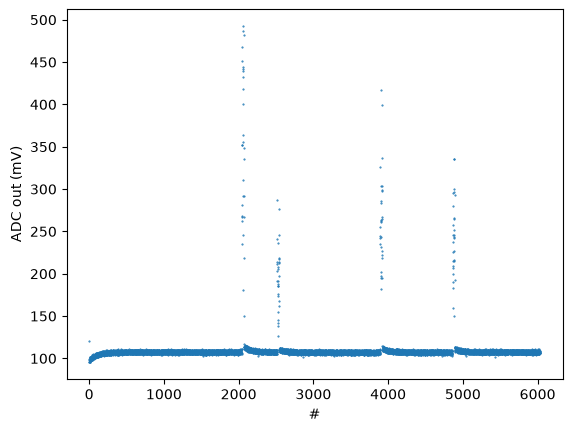

In [35]:
tag1.reflect(1)
tag1.begin_reading()
time.sleep(.2)
voltage_readings_newtag1=tag1.stop_reading()
print("Voltage array len:",len(voltage_readings_newtag1), )
plt.plot(voltage_readings_newtag1, '.',markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

b'ch: 3, ok\r\n' 	 b'ch: 3, ok\r\n'
Voltage array len: 5889


Text(0, 0.5, 'ADC out (mV)')

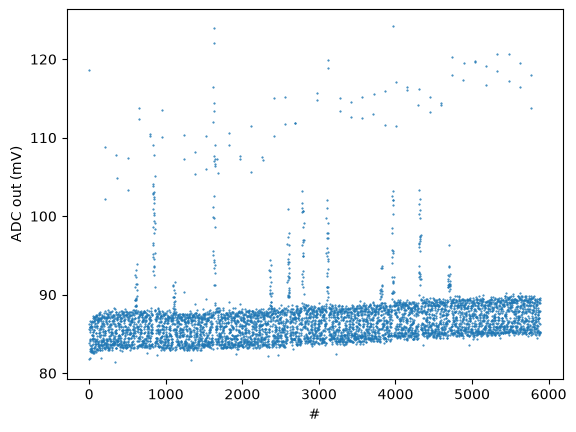

In [36]:
tag2.reflect(3)
tag2.begin_reading()
time.sleep(0.2)
voltage_readings_newtag2=tag2.stop_reading()
print("Voltage array len:",len(voltage_readings_newtag2))
plt.plot(voltage_readings_newtag2, '.', markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

In [37]:
# tag3.reflect(1)
# tag3.begin_reading()
# time.sleep(10)
# voltage_readings_newtag3=tag3.stop_reading()
# print("Voltage array len:",len(voltage_readings_newtag3), )
# plt.plot(voltage_readings_newtag3, '.', markersize=1)
# plt.xlabel("#")
# plt.ylabel("ADC out (mV)")

Begin reading
Starting MPP
Reading response
Got 352 readings.
  segment 0 [0.00539, 0.00644): 32 readings
  segment 1 [0.00644, 0.00749): 31 readings
  segment 2 [0.00749, 0.00854): 32 readings
  segment 3 [0.00854, 0.00959): 31 readings
  segment 4 [0.00959, 0.01064): 32 readings
  segment 5 [0.01064, 0.01169): 31 readings
Begin reading
Starting MPP
Reading response
Got 340 readings.
  segment 0 [0.00514, 0.00619): 31 readings
  segment 1 [0.00619, 0.00724): 31 readings
  segment 2 [0.00724, 0.00829): 31 readings
  segment 3 [0.00829, 0.00934): 31 readings
  segment 4 [0.00934, 0.01039): 31 readings
  segment 5 [0.01039, 0.01144): 31 readings
Begin reading
Starting MPP
Reading response
Got 364 readings.
  segment 0 [0.00587, 0.00692): 31 readings
  segment 1 [0.00692, 0.00797): 31 readings
  segment 2 [0.00797, 0.00902): 32 readings
  segment 3 [0.00902, 0.01007): 31 readings
  segment 4 [0.01007, 0.01112): 31 readings
  segment 5 [0.01112, 0.01217): 31 readings
Begin reading
Starting

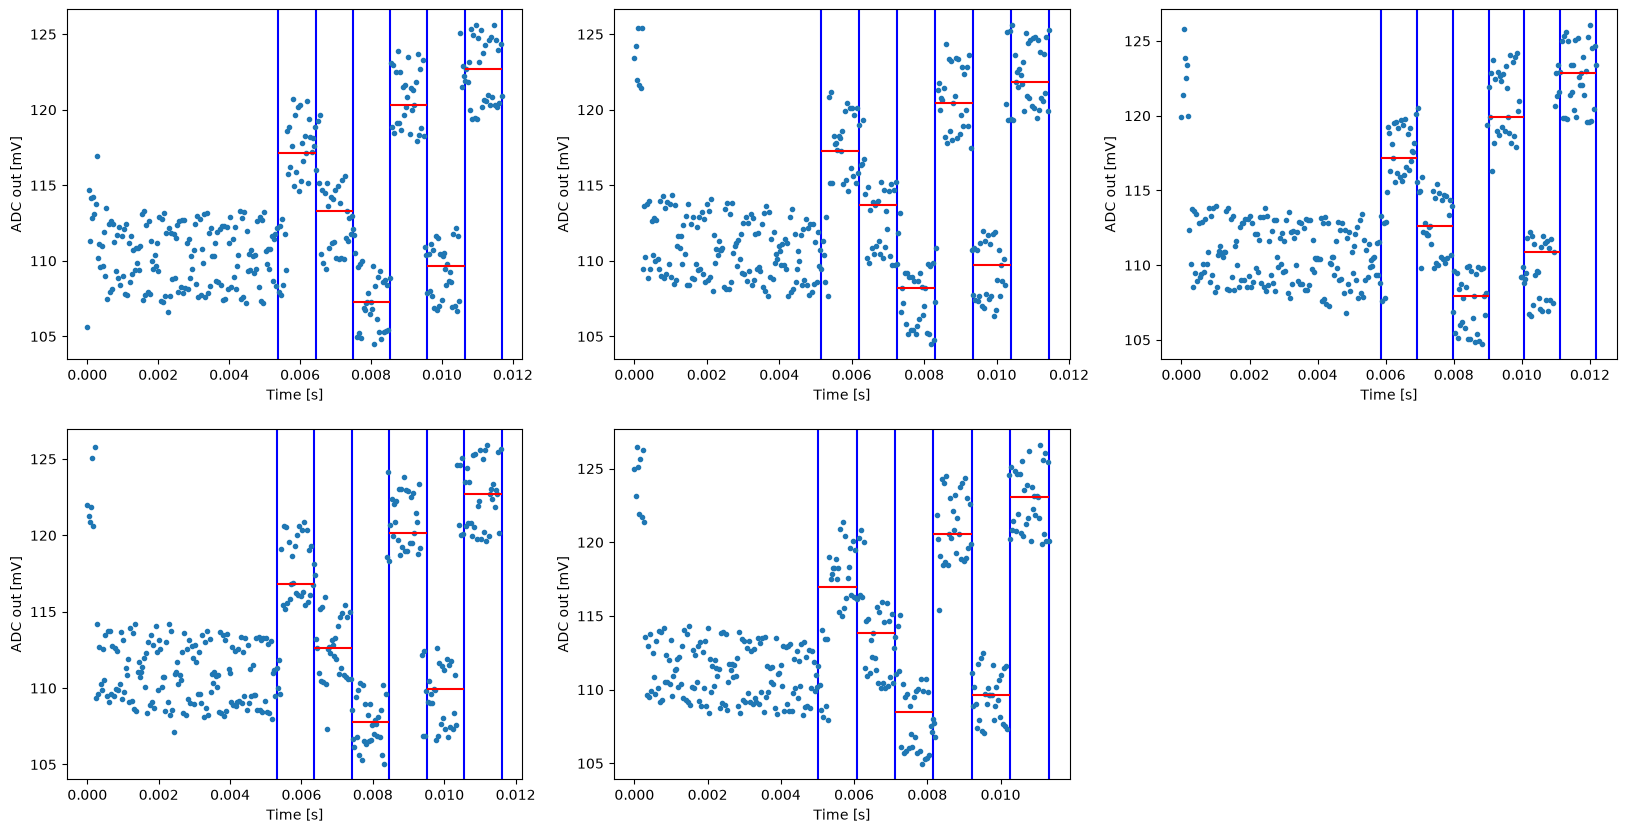

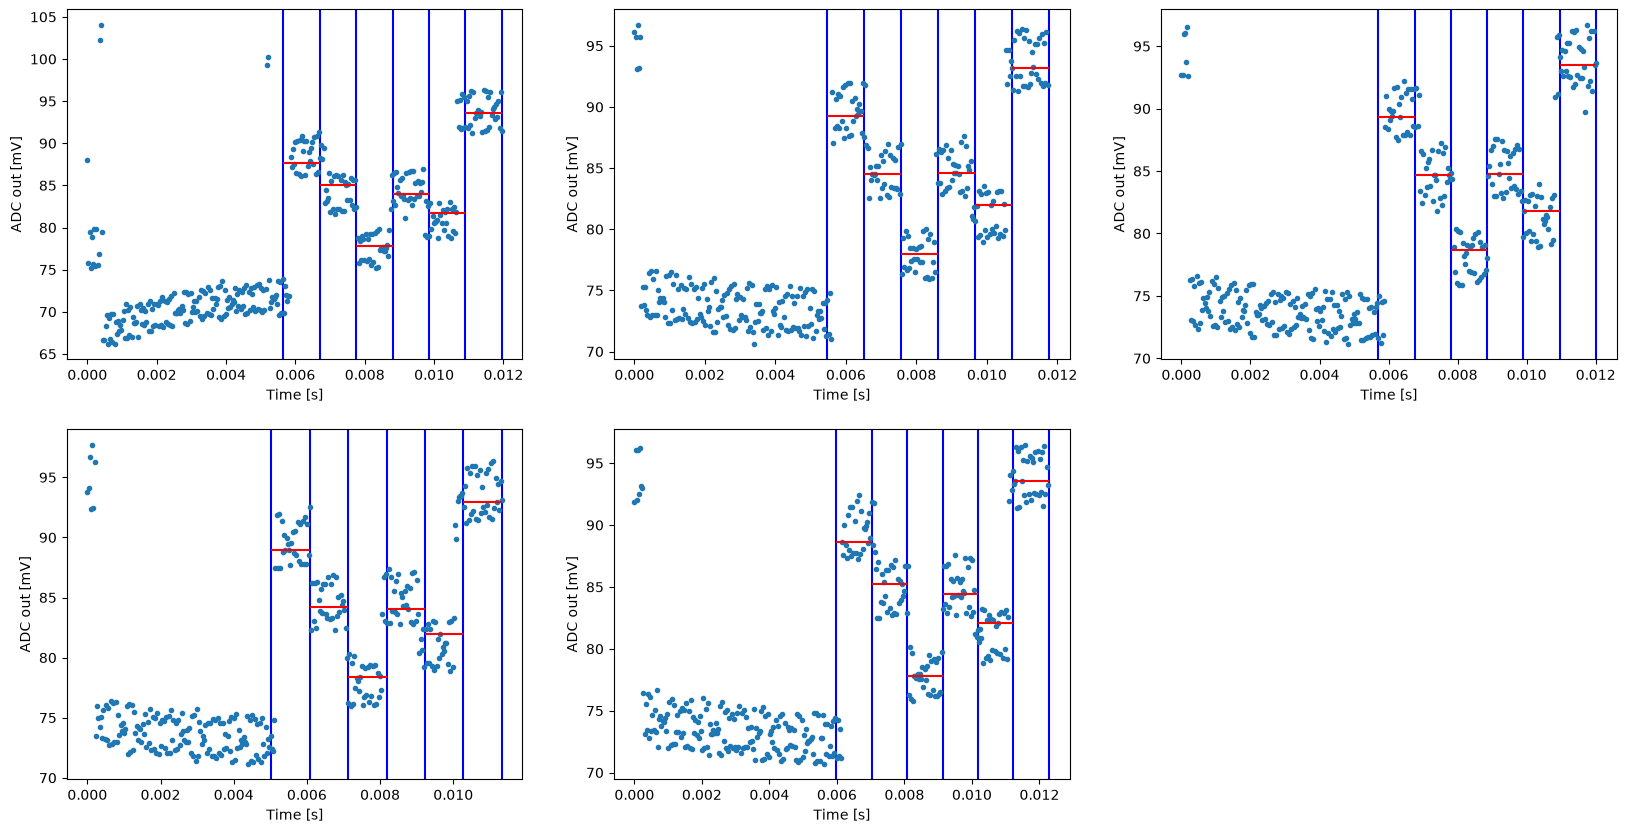

In [38]:
def plotMPPs(t1, t2):
    plt.figure(figsize=(20,10))
    for rep in range(5):
        plt.subplot(2,3,rep+1)
        print("Begin reading")     
        t1.begin_reading()

        print("Starting MPP")     
        mpp_start_time,mpp_stop_time=t2.perform_mpp()

        print("Reading response")
        voltage_readings=t1.stop_reading()
        print(f"Got {len(voltage_readings)} readings.")

        mpp_time_elapsed=mpp_stop_time-mpp_start_time
        plot_all_time=np.arange(0,mpp_time_elapsed,mpp_time_elapsed/len(voltage_readings))
        plot_end_time=plot_all_time[-1]
        ver_lines=[]
        for i in range(7):
            ver_lines.append(plot_end_time-0.00105*(i))

        for v in ver_lines:
            plt.axvline(x = v, color = 'b', label = 'axvline - full height')

        plot_time=plot_all_time[:len(voltage_readings)]
        plot_voltage=np.asarray(voltage_readings)[:len(plot_time)]

        plt.plot(plot_time,plot_voltage, '.')

        # Median of the readings falling between each adjacent pair of blue lines,
        # drawn on top of the data trace.
        for seg,(left,right) in enumerate(zip(sorted(ver_lines)[:-1],sorted(ver_lines)[1:])):
            in_segment=(plot_time>=left)&(plot_time<right)
            print(f"  segment {seg} [{left:.5f}, {right:.5f}): {np.count_nonzero(in_segment)} readings")
            if not np.any(in_segment):
                continue
            plt.hlines(np.median(plot_voltage[in_segment]),left,right,color='r',zorder=3)

        plt.xlabel("Time [s]")
        plt.ylabel("ADC out [mV]")
plotMPPs(t1=tag1, t2=tag2)
plotMPPs(t1=tag2, t2=tag1)
